In [87]:
import pandas as pd
import scikit_posthocs as sp
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ptitprince1 as pt
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

# stats functions

In [88]:
def stats_test(df, tertile_var, probabilities):
    # noramlity test
    for tertile in df[tertile_var].unique():
        data = df[df[tertile_var] == tertile][probabilities]
        stat, p = stats.shapiro(data)
        print(f"Normality test for {tertile}: Statistics={stat:.2f}, p={p:.2e}")

    # homogeneity of variances
    grouped_data = [df[df[tertile_var] == tertile][probabilities] for tertile in df[tertile_var].unique()]
    stat, p = stats.levene(*grouped_data)
    print(f"Levene's test for homogeneity of variances: Statistics={stat:.2f}, p={p:.2e}")

In [89]:
from scipy.stats import mannwhitneyu

def mann_whitney_test_tau(df, group_col, value_col):
    groups = df[group_col].unique()
    
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups for Mann-Whitney test, but found {len(groups)}")
    
    group1_data = df[df[group_col] == groups[0]][value_col]
    group2_data = df[df[group_col] == groups[1]][value_col]
    
    statistic, p_value = mannwhitneyu(group1_data, group2_data, alternative='less')
    
    if value_col == 'amy_CENTILOIDS':
        table_value = 'CL' 
    elif value_col == 'amy_label_prob':
        table_value = 'P(Aβ)' 
    elif value_col == 'tau_META_VILLE_SUVR':
        table_value = 'Meta-τ SUVR'
    elif value_col == 'tau_label_prob':
        table_value = 'P(τ)' 
    result_df = pd.DataFrame({
        'Measure': [table_value],
        'U Statistic': [statistic],
        'p-value': [f'{p_value:.2e}']
    })
    
    
    return result_df

# Load data

In [90]:
df = pd.read_csv('data/fig3_fig4_all_data.csv')
df

,amy_label_label,tau_label_label,amy_label_prob,tau_label_prob,cdr_CDRGLOB,COHORT,tau_front_label_label,tau_occ_label_label,tau_medtemp_label_label,tau_lattemp_label_label,...,cd_NACCUDSD,amy_CENTILOIDS,tau_PARIETAL_SUVR,tau_META_VILLE_SUVR,tau_MEDIAL_TEMPORAL_SUVR,tau_LATERAL_TEMPORAL_SUVR,tau_MEDIAL_PARIETAL_SUVR,tau_LATERAL_PARIETAL_SUVR,tau_OCCIPITAL_SUVR,tau_FRONTAL_SUVR
0,0,0.0,0.410,0.403,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-15.0,NaN,1.105241,1.079772,1.062204,1.061575,0.981454,1.017863,0.989466
1,1,0.0,0.431,0.537,0.5,ADNI,0.0,0.0,0.0,0.0,...,3.0,61.0,NaN,1.225454,1.278876,1.150311,1.068291,1.072042,1.137212,1.096695
2,0,0.0,0.423,0.410,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-9.0,NaN,1.210298,1.220804,1.128454,1.166971,1.024162,1.137282,1.125059
3,1,1.0,0.374,0.391,0.0,ADNI,0.0,0.0,1.0,0.0,...,0.0,46.0,NaN,1.410974,1.479579,1.248403,1.219296,1.072145,1.157214,1.206941
4,1,0.0,0.325,0.341,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,130.0,NaN,1.168234,1.176571,1.103342,1.082553,1.023759,1.075810,1.073625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1828,1,NaN,0.435,0.572,2.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1829,0,NaN,0.624,0.773,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1830,1,NaN,0.547,0.724,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1831,1,NaN,0.555,0.742,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Density Plots by Profile

In [91]:
cmap = plt.get_cmap('Set2')
group_colors = [cmap(1), cmap(2)]

df['Profile'] = df.apply(lambda x: 'Aβ+, τ+' if x['amy_label_label'] == 1 and x['tau_label_label'] == 1 
                        else ('Aβ-, τ-' if x['amy_label_label'] == 0 and x['tau_label_label'] == 0
                              else 'Other'), axis=1)

df_filtered = df[df['Profile'].isin(['Aβ+, τ+', 'Aβ-, τ-'])]

In [92]:
df_filtered['COHORT'].value_counts()

COHORT
ADNI    473
HABS    121
NACC     45
Name: count, dtype: int64

In [93]:
df = df[df['Profile'] != 'Other']
profile_labels=['Aβ+, τ+', 'Aβ-, τ-']

colors = ['#CC503E','#008080'] 

In [94]:
print(len(df))
df['Profile'].value_counts()

639


Profile
Aβ-, τ-    500
Aβ+, τ+    139
Name: count, dtype: int64

In [95]:
# normality test for pos
shapiro_amy_profile1 = stats.shapiro(df[df['Profile'] == 'Aβ+, τ+']['amy_label_prob'])
shapiro_amy_profile2 = stats.shapiro(df[df['Profile'] == 'Aβ-, τ-']['amy_label_prob'])

# normality test for neg
shapiro_tau_profile1 = stats.shapiro(df[df['Profile'] == 'Aβ+, τ+']['tau_label_prob'])
shapiro_tau_profile2 = stats.shapiro(df[df['Profile'] == 'Aβ-, τ-']['tau_label_prob'])

print("P(Aβ) Normality Test for Profile Aβ+, τ+: p-value =", shapiro_amy_profile1.pvalue)
print("P(Aβ) Normality Test for Profile Aβ-, τ-: p-value =", shapiro_amy_profile2.pvalue)
print("P(τ) Normality Test for Profile Aβ+, τ+: p-value =", shapiro_tau_profile1.pvalue)
print("P(τ) Normality Test for Profile Aβ-, τ-: p-value =", shapiro_tau_profile2.pvalue)


P(Aβ) Normality Test for Profile Aβ+, τ+: p-value = 0.293016254901886
P(Aβ) Normality Test for Profile Aβ-, τ-: p-value = 2.58985676871229e-13
P(τ) Normality Test for Profile Aβ+, τ+: p-value = 0.003674704348668456
P(τ) Normality Test for Profile Aβ-, τ-: p-value = 1.721965792178537e-09


In [96]:
# comparing P(AB) between positive and negative combined profiles
group1_amy = df[df['Profile'] == 'Aβ+, τ+']['amy_label_prob']
group2_amy = df[df['Profile'] == 'Aβ-, τ-']['amy_label_prob']

u_stat_amy, p_value_amy = stats.mannwhitneyu(group1_amy, group2_amy, alternative='greater')
print(f"Mann-Whitney U Test for P(Aβ): U statistic = {u_stat_amy:.2f}, p-value = {p_value_amy:.2e}")

# comparing P(tau) between positive and negative combined profiles
group1_tau = df[df['Profile'] == 'Aβ+, τ+']['tau_label_prob']
group2_tau = df[df['Profile'] == 'Aβ-, τ-']['tau_label_prob']

u_stat_tau, p_value_tau = stats.mannwhitneyu(group1_tau, group2_tau, alternative='greater')
print(f"Mann-Whitney U Test for P(τ): U statistic = {u_stat_tau:.2f}, p-value = {p_value_tau:.2e}")

Mann-Whitney U Test for P(Aβ): U statistic = 61430.00, p-value = 5.71e-44
Mann-Whitney U Test for P(τ): U statistic = 60963.00, p-value = 1.63e-42


In [97]:
def add_stat_significance(fig, x_start, x_end, y_start, y_end, text, orientation):
    if orientation == 'horizontal':
        # Horizontal Line
        fig.add_shape(type="line", x0=x_start, y0=y_start, x1=x_end, y1=y_start, line=dict(color="black", width=2))
        # Ticks
        fig.add_shape(type="line", x0=x_start, y0=y_start, x1=x_start, y1=y_start + 0.02, line=dict(color="black", width=2))
        fig.add_shape(type="line", x0=x_end, y0=y_start, x1=x_end, y1=y_start + 0.02, line=dict(color="black", width=2))
        # Text
        fig.add_annotation(x=(x_start + x_end) / 2, y=y_start + 0.02, text=text, showarrow=False, font=dict(size=14))
    else:
        # Vertical Line
        fig.add_shape(type="line", x0=x_start, y0=y_start, x1=x_start, y1=y_end, line=dict(color="black", width=2))
        # Ticks
        fig.add_shape(type="line", x0=x_start, y0=y_start, x1=x_start - 0.02, y1=y_start, line=dict(color="black", width=2))
        fig.add_shape(type="line", x0=x_start, y0=y_end, x1=x_start - 0.02, y1=y_end, line=dict(color="black", width=2))
        # Text
        fig.add_annotation(x=x_start - 0.03, y=(y_start + y_end) / 2, text=text, showarrow=False, font=dict(size=14), textangle=-90)


In [98]:
df['COHORT'].value_counts()

COHORT
ADNI    473
HABS    121
NACC     45
Name: count, dtype: int64

In [99]:
df[['amy_label_prob', 'tau_label_prob', 'Profile', 'COHORT']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig4c.csv', index=False)

In [100]:
fontsizes = 16
cohort_markers = {
    'ADNI': 'circle',
    'HABS': 'cross',
    'NACC': 'diamond'
}

color_map = {'Aβ+, τ+': '#CC503E', 'Aβ-, τ-': '#008080'}

fig = px.density_contour(
    df,
    x='amy_label_prob',
    y='tau_label_prob',
    color='Profile',
    marginal_x='box',
    marginal_y='box',
    color_discrete_map=color_map,
    title=''
)

for trace in fig.data:
    if trace.type == 'contour':
        trace.line.width = 1
        trace.showlegend = True  

for i, trace in enumerate(fig.data):
    if trace.type in ['box', 'violin']:
        trace.showlegend = False

fig.add_trace(go.Scatter(
    x=df['amy_label_prob'],
    y=df['tau_label_prob'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['Profile'].map(color_map),
        symbol=df['COHORT'].map(cohort_markers)
    ),
    showlegend=False
))

for cohort, marker in cohort_markers.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(
            size=8,
            color='black',
            symbol=marker
        ),
        name=cohort,
        showlegend=True
    ))

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='P(Aβ)',
        title_font=dict(size=fontsizes),
        linecolor='black',
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=0.5,
        ticks='outside',
        tickcolor='black',
        ticklen=10,
        nticks=10
    ),
    yaxis=dict(
        title='P(τ)',
        title_font=dict(size=fontsizes),
        linecolor='black',
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=0.5,
        ticks='outside',
        tickcolor='black',
        ticklen=10,
        nticks=10
    ),
    legend=dict(
        title_text="",
        yanchor="top",
        y=1.2,
        xanchor="center",
        x=0.5,
        orientation="h",
        itemsizing="constant"
    ),
    font=dict(family="Arial, sans-serif", size=fontsizes, color="black")
)

fig.show()

# Export to PDF
fig_width_inch = 3
fig_height_inch = 1.5
dpi = 300
fig_width_px = fig_width_inch * dpi
fig_height_px = fig_height_inch * dpi
pio.write_image(fig, 'pdf_plots/fig4c.pdf', width=fig_width_px, height=fig_height_px)

# Tau tertiles

In [101]:
df = pd.read_csv('data/fig3_fig4_all_data.csv')
df

,amy_label_label,tau_label_label,amy_label_prob,tau_label_prob,cdr_CDRGLOB,COHORT,tau_front_label_label,tau_occ_label_label,tau_medtemp_label_label,tau_lattemp_label_label,...,cd_NACCUDSD,amy_CENTILOIDS,tau_PARIETAL_SUVR,tau_META_VILLE_SUVR,tau_MEDIAL_TEMPORAL_SUVR,tau_LATERAL_TEMPORAL_SUVR,tau_MEDIAL_PARIETAL_SUVR,tau_LATERAL_PARIETAL_SUVR,tau_OCCIPITAL_SUVR,tau_FRONTAL_SUVR
0,0,0.0,0.410,0.403,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-15.0,NaN,1.105241,1.079772,1.062204,1.061575,0.981454,1.017863,0.989466
1,1,0.0,0.431,0.537,0.5,ADNI,0.0,0.0,0.0,0.0,...,3.0,61.0,NaN,1.225454,1.278876,1.150311,1.068291,1.072042,1.137212,1.096695
2,0,0.0,0.423,0.410,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-9.0,NaN,1.210298,1.220804,1.128454,1.166971,1.024162,1.137282,1.125059
3,1,1.0,0.374,0.391,0.0,ADNI,0.0,0.0,1.0,0.0,...,0.0,46.0,NaN,1.410974,1.479579,1.248403,1.219296,1.072145,1.157214,1.206941
4,1,0.0,0.325,0.341,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,130.0,NaN,1.168234,1.176571,1.103342,1.082553,1.023759,1.075810,1.073625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1828,1,NaN,0.435,0.572,2.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1829,0,NaN,0.624,0.773,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1830,1,NaN,0.547,0.724,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1831,1,NaN,0.555,0.742,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
tau_df = df.dropna(subset=['tau_META_VILLE_SUVR'])
tau_df = tau_df[tau_df['COHORT'] != 'NACC']
tau_df['COHORT'].value_counts()

COHORT
ADNI    625
HABS    173
Name: count, dtype: int64

In [103]:
# get τ PET tertiles among those who are amyloid positive
filtered_df = tau_df[tau_df['amy_label_label'] == 1]
filtered_df['tau_tertile'], bins = pd.qcut(filtered_df['tau_META_VILLE_SUVR'], 3, labels=["Low τ PET", "Medium τ PET", "High τ PET"], retbins=True)
print("Tertile cutoff values for amy_label == 1:", bins)
print(filtered_df['tau_tertile'].value_counts())

Tertile cutoff values for amy_label == 1: [0.79060405 1.21803684 1.42762902 2.58760358]
tau_tertile
Low τ PET       102
High τ PET      102
Medium τ PET    100
Name: count, dtype: int64


/scratch/5475227.1.cbm.q/ipykernel_2917561/212127120.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [104]:
print(len(filtered_df))

304


In [105]:
amy_pos_df = filtered_df

In [106]:
# create combined low/med based on tau_tertile values
amy_pos_df['tau_level'] = amy_pos_df['tau_tertile'].apply(
    lambda x: 'High τ PET' if x == 'High τ PET' else 'Low/med τ PET'
)

/scratch/5475227.1.cbm.q/ipykernel_2917561/1980399999.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [107]:
amy_pos_df['tau_level'].value_counts()

tau_level
Low/med τ PET    202
High τ PET       102
Name: count, dtype: int64

## Stats

In [108]:
stats_test(amy_pos_df, 'tau_level', 'amy_CENTILOIDS')

Normality test for Low/med τ PET: Statistics=0.94, p=1.83e-07
Normality test for High τ PET: Statistics=0.95, p=9.67e-04
Levene's test for homogeneity of variances: Statistics=4.27, p=3.96e-02


In [109]:
stats_test(amy_pos_df, 'tau_level', 'amy_label_prob')

Normality test for Low/med τ PET: Statistics=0.97, p=8.48e-04
Normality test for High τ PET: Statistics=0.98, p=5.36e-02
Levene's test for homogeneity of variances: Statistics=0.26, p=6.11e-01


In [110]:
result_tau_tertile_CL = mann_whitney_test_tau(amy_pos_df, 'tau_level', 'amy_CENTILOIDS')
result_tau_tertile_CL

,Measure,U Statistic,p-value
0,CL,5047.0,1.92e-13


In [111]:
result_tau_tertile_amy_prob = mann_whitney_test_tau(amy_pos_df, 'tau_level', 'amy_label_prob')
result_tau_tertile_amy_prob

,Measure,U Statistic,p-value
0,P(Aβ),3707.0,4.01e-20


## Plot

In [112]:
amy_pos_df[['tau_level', 'amy_CENTILOIDS', 'amy_label_prob']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig4a.csv', index=False)

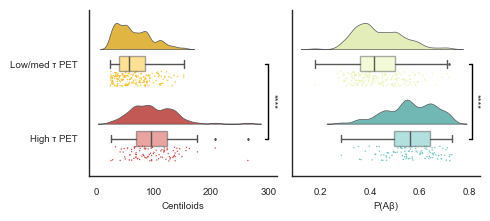

In [113]:
sns.set_theme(style="white", context="paper")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.3), sharey=True)
font_sizes = 7

# centiloids
cb_palette1 = sns.color_palette("inferno_r")
custom_pal1 = {'Low/med τ PET': cb_palette1[0], 'High τ PET': cb_palette1[2]}

pt.RainCloud(data = amy_pos_df, x = "tau_level", y = "amy_CENTILOIDS", orient='h', 
palette = custom_pal1, bw=.2, ax=ax1, move = .2, linewidth=0.5, dodge=True, 
width_viol=.7, width_box=0.2, point_size = 1, jitter=1, cut=3)

ax1.plot([300, 300], [0, 1], color='black', linewidth=2) # vert line
ax1.plot([300, 294], [0, 0], color='black', linewidth=2) # tick 1
ax1.plot([300, 294], [1, 1], color='black', linewidth=2) # tick 2
ax1.text(308, 0.5, "****", ha='center', va='center', rotation=270, fontname='Arial', fontsize=font_sizes) # stars

if ax1.get_yticks().size > 0:
    positions = ax1.get_yticks()
    labels = ['Low/med τ PET', 'High τ PET']
    ax1.set_yticks(positions[:len(labels)])
    ax1.set_yticklabels(labels)

ax1.set_xlabel("Centiloids", fontname='Arial', fontsize=font_sizes)
ax1.set_ylabel("", fontname='Arial', fontsize=font_sizes)
ax1.tick_params(axis='both', labelsize=font_sizes)

for c in ax1.get_children():
    if isinstance(c, plt.Line2D):
        c.set_linewidth(1)
    if isinstance(c, mpatches.Patch):
        c.set_linewidth(1)

# # prob amy
cb_palette = sns.color_palette("YlGnBu")
custom_pal = {'Low/med τ PET': cb_palette[0], 'High τ PET': cb_palette[2]}

pt.RainCloud(data = amy_pos_df, x = "tau_level", y = "amy_label_prob", orient='h', cut=3,
palette = custom_pal, bw=.2, ax=ax2, move = .2, linewidth=0.5, dodge=True,
width_viol=.7, width_box=0.2, point_size = 1, jitter=1)

ax2.plot([0.81, 0.81], [0, 1], color='black', linewidth=2) # vert line
ax2.plot([0.81, 0.80], [0, 0], color='black', linewidth=2) # tick 1
ax2.plot([0.81, 0.80], [1, 1], color='black', linewidth=2) # tick 2
ax2.text(0.83, 0.5, "****", ha='center', va='center', rotation=270, fontname='Arial', fontsize=font_sizes) # stars

ax2.set_xlabel("P(Aβ)", fontname='Arial', fontsize=font_sizes)
ax2.set_ylabel("", fontname='Arial', fontsize=font_sizes)
ax2.tick_params(axis='both', labelsize=font_sizes)

# makes lines thinner
for c in ax2.get_children():
    if isinstance(c, plt.Line2D):
        c.set_linewidth(1)
    if isinstance(c, mpatches.Patch):
        c.set_linewidth(1)

sns.despine()
plt.tight_layout()
plt.savefig('pdf_plots/fig4a.pdf', dpi=300)
plt.show()

# CL Tertiles

In [114]:
amy_pos_df['amy_tertile'], bins = pd.qcut(amy_pos_df['amy_CENTILOIDS'], 3, labels=["Low CL", "Medium CL", "High CL"], retbins=True)
print("Tertile cutoff values for amy_label == 1:", bins)
amy_pos_df['amy_tertile'] = amy_pos_df['amy_tertile'].astype('category')
print(amy_pos_df['amy_tertile'].value_counts())

Tertile cutoff values for amy_label == 1: [ 24.  54.  87. 264.]
amy_tertile
Low CL       106
High CL      101
Medium CL     97
Name: count, dtype: int64


/scratch/5475227.1.cbm.q/ipykernel_2917561/2256909519.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/scratch/5475227.1.cbm.q/ipykernel_2917561/2256909519.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [115]:
# create new column based on cl_level values
amy_pos_df['cl_level'] = amy_pos_df['amy_tertile'].apply(
    lambda x: 'High CL' if x == 'High CL' else 'Low/med CL'
)

/scratch/5475227.1.cbm.q/ipykernel_2917561/2533901753.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [116]:
amy_pos_df['cl_level'].value_counts()

cl_level
Low/med CL    203
High CL       101
Name: count, dtype: int64

## Stats

In [117]:
stats_test(amy_pos_df, 'cl_level', 'tau_META_VILLE_SUVR')

Normality test for Low/med CL: Statistics=0.88, p=1.32e-11
Normality test for High CL: Statistics=0.94, p=3.55e-04
Levene's test for homogeneity of variances: Statistics=8.29, p=4.27e-03


In [118]:
stats_test(amy_pos_df, 'cl_level', 'tau_label_prob')

Normality test for Low/med CL: Statistics=0.98, p=5.40e-03
Normality test for High CL: Statistics=0.96, p=1.97e-03
Levene's test for homogeneity of variances: Statistics=0.00, p=9.80e-01


In [119]:
result_amy_tertile_taupet = mann_whitney_test_tau(amy_pos_df, 'cl_level', 'tau_META_VILLE_SUVR')
result_amy_tertile_taupet

,Measure,U Statistic,p-value
0,Meta-τ SUVR,5876.0,6.78e-10


In [120]:
result_amy_tertile_tauprob = mann_whitney_test_tau(amy_pos_df, 'cl_level', 'tau_label_prob')
result_amy_tertile_tauprob

,Measure,U Statistic,p-value
0,P(τ),6655.5,3.17e-07


## Plot

In [121]:
amy_pos_df[['cl_level', 'tau_META_VILLE_SUVR', 'tau_label_prob']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig4b.csv', index=False)

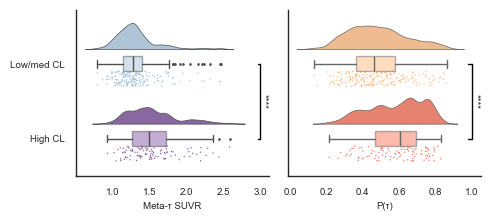

In [122]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.3), sharey=True)

# centiloids
font_sizes = 7
pt.RainCloud(data = amy_pos_df, x = "cl_level", y = "tau_META_VILLE_SUVR", orient='h', 
palette = "BuPu", bw=.2, ax=ax1, move = .2, linewidth=0.5, dodge=True, 
width_viol=.7, width_box=0.2, point_size = 1, jitter=1, cut=3)

ax1.plot([3, 3], [0, 1], color='black', linewidth=2) # vert line
ax1.plot([3, 2.97], [0, 0], color='black', linewidth=2) # tick 1
ax1.plot([3, 2.97], [1, 1], color='black', linewidth=2) # tick 2
ax1.text(3.05, 0.5, "****", ha='center', va='center', rotation=270, fontname='Arial', fontsize=font_sizes) # stars

ax1.set_xlabel("Meta-τ SUVR", fontname='Arial', fontsize=font_sizes)
ax1.set_ylabel("", fontname='Arial', fontsize=font_sizes)
ax1.tick_params(axis='both', labelsize=font_sizes)

for c in ax1.get_children():
    if isinstance(c, plt.Line2D):
        c.set_linewidth(1)
    if isinstance(c, mpatches.Patch):
        c.set_linewidth(1)

# # prob amy
cb_palette = sns.color_palette("magma_r")
custom_pal = {'Low/med CL': cb_palette[3], 'High CL': cb_palette[5]}

pt.RainCloud(data=amy_pos_df, x="cl_level", y="tau_label_prob", orient='h', cut=3,
             palette=cb_palette, bw=.2, ax=ax2, move=.2, linewidth=0.5, dodge=True,
             width_viol=.7, width_box=0.2, point_size=1, jitter=1)

ax2.plot([1, 1], [0, 1], color='black', linewidth=2) # vert line
ax2.plot([1, 0.98], [0, 0], color='black', linewidth=2) # tick 1
ax2.plot([1, 0.98], [1, 1], color='black', linewidth=2) # tick 2
ax2.text(1.025, 0.5, "****", ha='center', va='center', rotation=270, fontname='Arial', fontsize=font_sizes) # stars


ax2.set_xlabel("P(τ)", fontname='Arial', fontsize=font_sizes)
ax2.set_ylabel("", fontname='Arial', fontsize=font_sizes)
ax2.tick_params(axis='both', labelsize=font_sizes)

# makes lines thinner
for c in ax2.get_children():
    if isinstance(c, plt.Line2D):
        c.set_linewidth(1)
    if isinstance(c, mpatches.Patch):
        c.set_linewidth(1)

sns.despine()
plt.tight_layout()

plt.savefig('pdf_plots/fig4b.pdf', dpi=300)
plt.show()

# Print results stats tables

In [123]:
results_tables_rainclouds = pd.concat([result_tau_tertile_amy_prob, result_tau_tertile_CL, result_amy_tertile_tauprob, result_amy_tertile_taupet])
print(results_tables_rainclouds.to_latex())

\begin{tabular}{llrl}
\toprule
 & Measure & U Statistic & p-value \\
\midrule
0 & P(Aβ) & 3707.000000 & 4.01e-20 \\
0 & CL & 5047.000000 & 1.92e-13 \\
0 & P(τ) & 6655.500000 & 3.17e-07 \\
0 & Meta-τ SUVR & 5876.000000 & 6.78e-10 \\
\bottomrule
\end{tabular}

